In [ ]:
# import packages
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm  
import pandas as pd
import time
import pickle
import types
import os
import scipy
import psutil
import itertools
import re
import skimage

# from concurrent.futures import ThreadPoolExecutor  
# from multiprocessing import Pool 
import seaborn as sns
import scanpy as sc

import importlib

sc.set_figure_params(dpi=80)

# %load_ext line_profiler # only needed for profiling functions

In [ ]:
import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize


In [ ]:
def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = np.array([bind.get(itm, None) for itm in a])  # None can be replaced by any other "not in b" value
    result = [result, np.array([not x is None for x in result])]
    return result

def write_object(myObject, file):
    import dill
    with open(file, 'wb') as f:
        f.write(dill.dumps(myObject))

def read_object(file):
    import dill
    with open(file, 'rb') as f:
        myObject = dill.loads(f.read())
    return myObject

def flatten(my_list):
    return(list(itertools.chain(*my_list)))
    
def grep(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[valid_entries]
    
def grep_exclude(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[np.logical_not(valid_entries)]

In [ ]:
preprocessed_path = "../preprocessed/"
possible_files = grep("epi", os.listdir(preprocessed_path))

In [ ]:
result = []
for my_file in possible_files:
    adata_temp = sc.read_h5ad(os.path.join(preprocessed_path, my_file))
    del adata_temp.obs['nucleus_eroded_area']
    del adata_temp.obs['nucleus_eroded_solidity']
    sc.write(os.path.join(preprocessed_path, my_file), adata = adata_temp)
    

In [ ]:
result = []
for my_file in possible_files:
    adata_temp = sc.read_h5ad(os.path.join(preprocessed_path, my_file))
    adata_temp.X = adata_temp.layers['raw'].copy()
    sc.pp.log1p(adata_temp)
    sc.pp.scale(adata_temp)
    result.append(adata_temp)

In [ ]:
adata = sc.concat(result)

In [ ]:
obs_path = "../obs/"
possible_files = grep("csv", os.listdir(obs_path))

In [ ]:
result = []
for my_file in possible_files:
    result.append(pd.read_csv(os.path.join(obs_path, my_file), index_col = 0))

In [ ]:
result = pd.concat(result)

In [ ]:
result = result.loc[adata.obs_names.to_numpy(),:].copy()
adata.obs = result.copy()

In [ ]:
condition_map = {
    'JR-sp-15-011': 'vehicle',
    'JR-sp-15-010': 'mrtx',
    'JR-sp-40-11': 'vehicle',
    'JR-sp-40-13': 'mrtx',
    'JR-sp-40-17': 'mrtx',    
}
adata.obs['condition'] = adata.obs['slide_id'].map(condition_map)

In [ ]:
apoptosis_rate = adata.obs[['cell_type_0', 'cc3_positive', 'slide_id', 'condition']].groupby(['cell_type_0', 'slide_id', 'condition']).agg('mean').reset_index()
apoptosis_rate_per_condition = apoptosis_rate.loc[:,['cell_type_0', 'cc3_positive', 'condition']].groupby(['cell_type_0', 'condition']).agg(lambda x: np.median(x)).reset_index()


progenitor_gastric_pval = 0.0495
progenitor_adm_pval = 0.0495
progenitor_other_pval = 0.0495
gastric_adm_pval = 0.0495
gastric_other_pval = 0.0495
adm_other_pval = 0.0495


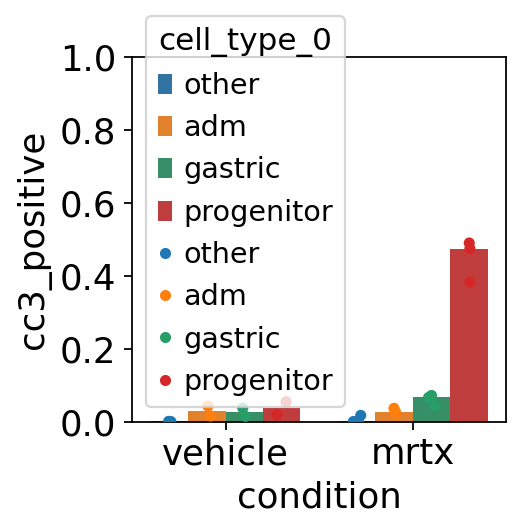

In [ ]:
import seaborn as sns
plt.figure(figsize = [3,3])
condition_order = ['vehicle', 'mrtx']
hue_order = ['other', 'adm', 'gastric', 'progenitor']
sns.barplot(x = 'condition', y = 'cc3_positive', hue = 'cell_type_0', data = apoptosis_rate_per_condition, order = condition_order, hue_order = hue_order)
sns.stripplot(x = 'condition', y = 'cc3_positive', hue = 'cell_type_0', data = apoptosis_rate, order = condition_order, hue_order = hue_order,  dodge = True, size = 5)
plt.ylim([0,1])

progenitor_val = apoptosis_rate['cc3_positive'][np.logical_and(apoptosis_rate['condition'] == 'mrtx', apoptosis_rate['cell_type_0'] == 'progenitor')].to_numpy()
gastric_val = apoptosis_rate['cc3_positive'][np.logical_and(apoptosis_rate['condition'] == 'mrtx', apoptosis_rate['cell_type_0'] == 'gastric')].to_numpy()
adm_val = apoptosis_rate['cc3_positive'][np.logical_and(apoptosis_rate['condition'] == 'mrtx', apoptosis_rate['cell_type_0'] == 'adm')].to_numpy()
other_val = apoptosis_rate['cc3_positive'][np.logical_and(apoptosis_rate['condition'] == 'mrtx', apoptosis_rate['cell_type_0'] == 'other')].to_numpy()

progenitor_gastric_pval = f"{scipy.stats.ranksums(progenitor_val, gastric_val).pvalue:.4f}"
progenitor_adm_pval = f"{scipy.stats.ranksums(progenitor_val, adm_val).pvalue:.4f}"
progenitor_other_pval = f"{scipy.stats.ranksums(progenitor_val, other_val).pvalue:.4f}"
gastric_adm_pval = f"{scipy.stats.ranksums(gastric_val, adm_val).pvalue:.4f}"
gastric_other_pval = f"{scipy.stats.ranksums(gastric_val, other_val).pvalue:.4f}"
adm_other_pval = f"{scipy.stats.ranksums(adm_val, other_val).pvalue:.4f}"

print('progenitor_gastric_pval = ' + progenitor_gastric_pval)
print('progenitor_adm_pval = ' + progenitor_adm_pval)
print('progenitor_other_pval = ' + progenitor_other_pval)
print('gastric_adm_pval = ' + gastric_adm_pval)
print('gastric_other_pval = ' + gastric_other_pval)
print('adm_other_pval = ' + adm_other_pval)


### Get cell type fractions per mouse

In [ ]:
adata_sub = adata[adata.obs['cell_type_0'] != "other",:].copy()

In [ ]:
cell_type_count = adata_sub.obs[['cell_type_0', 'slide_id', 'condition', 'cc3_positive']].groupby(['cell_type_0', 'slide_id', 'condition']).agg('count').reset_index()
cell_type_count.columns = ['cell_type_0', 'slide_id', 'condition', 'count']
total_count = adata_sub.obs[['slide_id', 'condition', 'cc3_positive']].groupby(['slide_id', 'condition']).agg('count').reset_index()
total_count.index = total_count['slide_id']
cell_type_count['normalization'] = total_count.loc[cell_type_count['slide_id'],"cc3_positive"].to_numpy()

In [ ]:
cell_type_count['relative_freq'] = cell_type_count['count'] / cell_type_count['normalization']

<Axes: xlabel='slide_id'>

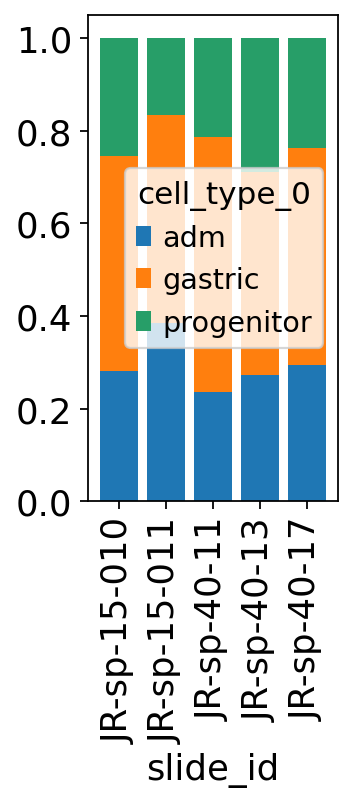

In [ ]:
f, ax = plt.subplots(1,1,figsize = [2,4])
mat = cell_type_count.pivot_table(index='slide_id', columns='cell_type_0', values='relative_freq')
mat.plot(kind = 'bar', stacked = True, width = 0.8, ax = ax)


In [ ]:
def annotate_groups(adata_sub, grouping):
    adata_sub.obs['group_id'] = adata_sub.obs[grouping].apply(lambda row: '_'.join(row.astype(str)), axis=1)
    group_counts = adata_sub.obs['group_id'].value_counts()
    adata_sub.obs['group_id'] = [x + " (n = " + str(group_counts.loc[x]) + ")" for x in adata_sub.obs['group_id']]

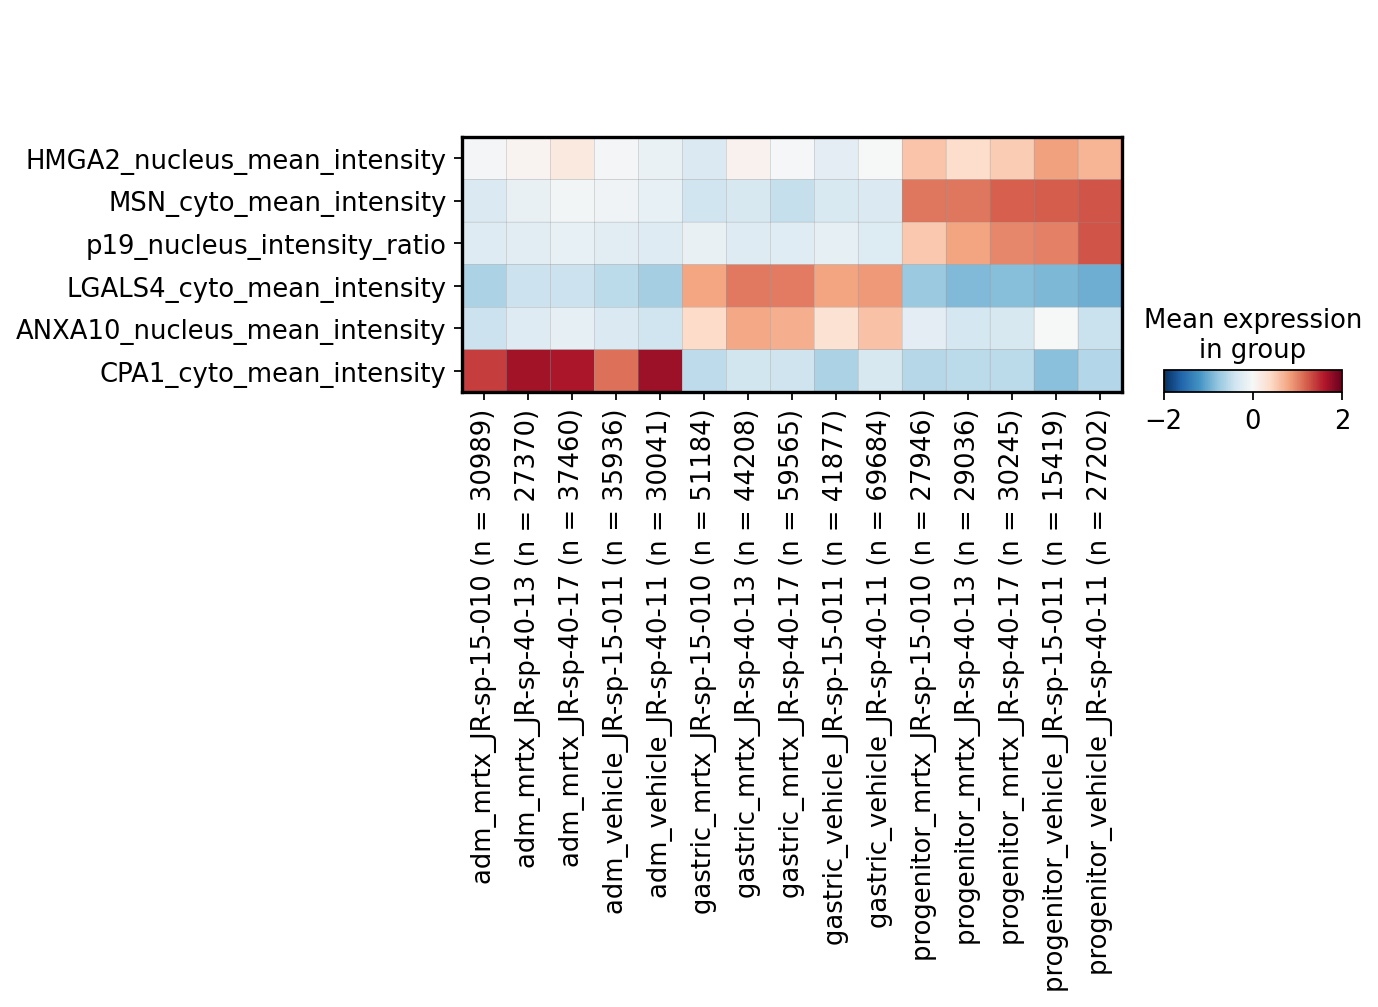

/tmp/ipykernel_3916655/2810451099.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df.groupby('grouping').agg('mean')


In [ ]:
annotate_groups(adata_sub, ['cell_type_0', 'condition', 'slide_id'])
selected_vars = ['HMGA2_nucleus_mean_intensity', 'MSN_cyto_mean_intensity', 'p19_nucleus_intensity_ratio', 'LGALS4_cyto_mean_intensity', 'ANXA10_nucleus_mean_intensity', 'CPA1_cyto_mean_intensity']
sc.pl.matrixplot(
    adata_sub, groupby = 'group_id', 
    var_names = selected_vars, swap_axes = True, vmin = -2, vmax = 2, cmap = 'RdBu_r',
)
df = pd.DataFrame(adata_sub[:,selected_vars].X, columns = selected_vars, index = adata_sub.obs_names)
df['grouping'] = adata_sub.obs['group_id']
df_summary = df.groupby('grouping').agg('mean')
